# SEAI Monthly Electricity Statistics

Exploration of the seai data on Ireland's electricity. The original seai site is a lot more detailed. 

* https://www.seai.ie/data-and-insights/seai-statistics/monthly-energy-data/electricity-monthly
* https://public.tableau.com/app/profile/lee.carroll/viz/Electricity-EnhancedMonthlyPanels/13



In [1]:
filename = "AA_electricity_monthly.csv"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets

In [3]:
df = pd.read_csv(filename, sep="\t")
df.head(1)

,Year of Period,Month of Period,Unit,Coal,Combust. Renew.,Hydro,Interconnect - Exports,Interconnect - Imports,Natural Gas,Oil,Other,Peat & BM,Pumped Storage - Input,Pumped Storage - Output,Solar Farms,Wastes,Wind
0,2025,January,GWh,102,13,87,-53,407,1454,39,1,54,-55,36,29,53,1101


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Year of Period           192 non-null    int64
 1   Month of Period          192 non-null    str  
 2   Unit                     192 non-null    str  
 3   Coal                     192 non-null    int64
 4   Combust. Renew.          192 non-null    int64
 5   Hydro                    192 non-null    int64
 6   Interconnect - Exports   192 non-null    int64
 7   Interconnect - Imports   192 non-null    int64
 8   Natural Gas              192 non-null    int64
 9   Oil                      192 non-null    int64
 10  Other                    192 non-null    int64
 11  Peat & BM                192 non-null    int64
 12  Pumped Storage - Input   192 non-null    int64
 13  Pumped Storage - Output  192 non-null    int64
 14  Solar Farms              192 non-null    int64
 15  Wastes           

Sort the dataframe by year and month

In [5]:
df_sorted = df.copy()
df_sorted['Year of Period'] = df_sorted['Year of Period'].astype(str)
df_sorted['Period'] = df_sorted[['Year of Period', 'Month of Period']].agg('-'.join, axis=1)
df_sorted["Period"] = pd.to_datetime(df_sorted["Period"], format="%Y-%B")
df_sorted = df_sorted.sort_values("Period", ascending=True)
df_sorted

,Year of Period,Month of Period,Unit,Coal,Combust. Renew.,Hydro,Interconnect - Exports,Interconnect - Imports,Natural Gas,Oil,Other,Peat & BM,Pumped Storage - Input,Pumped Storage - Output,Solar Farms,Wastes,Wind,Period
180,2010,January,GWh,400,0,97,-4,138,1474,77,20,195,-50,30,0,0,248,2010-01-01
181,2010,February,GWh,407,0,60,-8,108,1395,29,22,190,-44,27,0,0,151,2010-02-01
182,2010,March,GWh,308,0,29,-13,74,1592,16,22,172,-48,30,0,0,251,2010-03-01
183,2010,April,GWh,233,0,74,-19,51,1368,14,23,213,-46,28,0,0,186,2010-04-01
184,2010,May,GWh,272,0,13,-3,105,1354,7,19,177,-45,28,0,0,169,2010-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,2025,August,GWh,0,12,7,-37,579,1196,1,1,45,-52,35,138,51,764,2025-08-01
8,2025,September,GWh,0,11,56,-33,581,986,13,1,43,-54,38,101,55,963,2025-09-01
9,2025,October,GWh,0,12,84,-59,562,1147,17,1,51,-50,34,50,57,1133,2025-10-01
10,2025,November,GWh,0,13,87,-38,572,1293,6,1,43,-54,36,32,49,1107,2025-11-01


Clean the data by dropping the Period index, and interconnect and pumped storage data.

In [6]:
df_clean = df_sorted.drop(columns=["Interconnect - Exports", "Interconnect - Imports", "Pumped Storage - Input", "Pumped Storage - Output"])
# df_clean = df_clean.sort_values("Period")
df_clean = df_clean.drop(columns="Period")
df_clean = df_clean.set_index(["Year of Period", "Month of Period"], drop=False)
df_clean.info()

<class 'pandas.DataFrame'>
MultiIndex: 192 entries, ('2010', 'January') to ('2025', 'December')
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Year of Period   192 non-null    str  
 1   Month of Period  192 non-null    str  
 2   Unit             192 non-null    str  
 3   Coal             192 non-null    int64
 4   Combust. Renew.  192 non-null    int64
 5   Hydro            192 non-null    int64
 6   Natural Gas      192 non-null    int64
 7   Oil              192 non-null    int64
 8   Other            192 non-null    int64
 9   Peat & BM        192 non-null    int64
 10  Solar Farms      192 non-null    int64
 11  Wastes           192 non-null    int64
 12  Wind             192 non-null    int64
dtypes: int64(10), str(3)
memory usage: 20.2+ KB


In [7]:
df_clean.head()

Year of Period Month of Period Unit  Coal  \
Year of Period Month of Period                                             
2010           January                   2010         January  GWh   400   
               February                  2010        February  GWh   407   
               March                     2010           March  GWh   308   
               April                     2010           April  GWh   233   
               May                       2010             May  GWh   272   

                                Combust. Renew.  Hydro  Natural Gas  Oil  \
Year of Period Month of Period                                             
2010           January                        0     97         1474   77   
               February                       0     60         1395   29   
               March                          0     29         1592   16   
               April                          0     74         1368   14   
               May                            0     13         1354    7   

                                Other  Peat & BM  Solar Farms  Wastes  Wind  
Year of Period Month of Period                                               
2010           January             20        195            0       0   248  
               February            22        190            0       0   151  
               March               22        172            0       0   251  
               April               23        213            0       0   186  
               May                 19        177            0       0   169

<Axes: xlabel='Year of Period,Month of Period'>

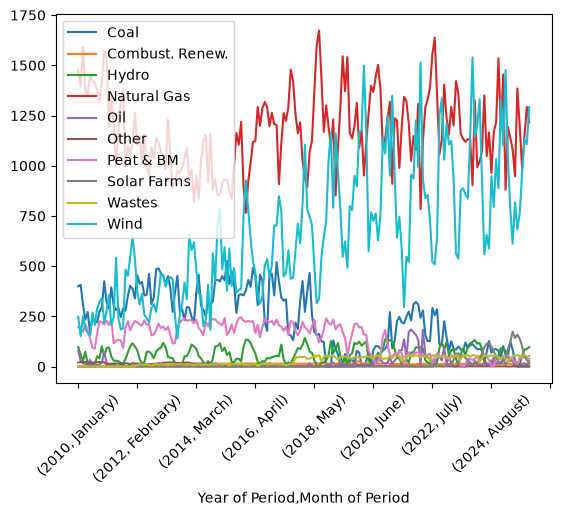

In [8]:
df_clean.plot(rot=45)

<Axes: xlabel='Year of Period,Month of Period'>

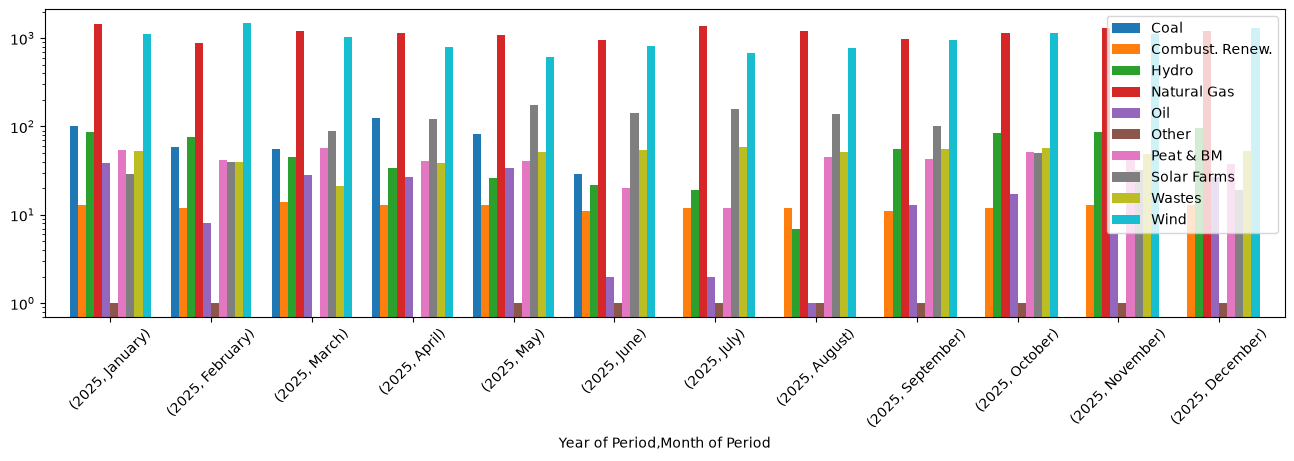

In [9]:
fig, ax = plt.subplots(figsize=(16,4))
# plt.ylabel("GWh")
df3 = df_clean[df_clean["Year of Period"] == "2025"]
df3.plot(ax=ax, rot=45, kind="bar", logy=True, width=0.8)

In [10]:
odf = df_clean

options = odf.select_dtypes(include="number").columns
years = list(odf['Year of Period'].unique())
years = years[::-1]
unit = odf['Unit'].iloc[0]  # assuming unique

def update_plot(fuels, years):
    fig, ax = plt.subplots(figsize=(16,8))
    df3 = odf[odf['Year of Period'].isin(years)]
    df3 = df3[list(fuels)]
    df3.sum(axis=1).plot(rot=45)
    df3.plot(ax=ax, rot=45, ylabel=unit, kind="bar", stacked=True, width=0.9)  # , ylim=(0, 1800))

widgets = dict(
    fuels=ipywidgets.SelectMultiple(
        options=options,
        value=list(options),
        rows=10,
        description='Fuel',
        disabled=False
    ),
    years=ipywidgets.SelectMultiple(
        options=years,
        value=["2025"],
        rows=10,
        description='Years',
        disabled=False
    )
)

plotwidget = ipywidgets.interactive_output(update_plot, widgets)

layout = ipywidgets.HBox(tuple(widgets.values()))
ipywidgets.VBox((layout, plotwidget))